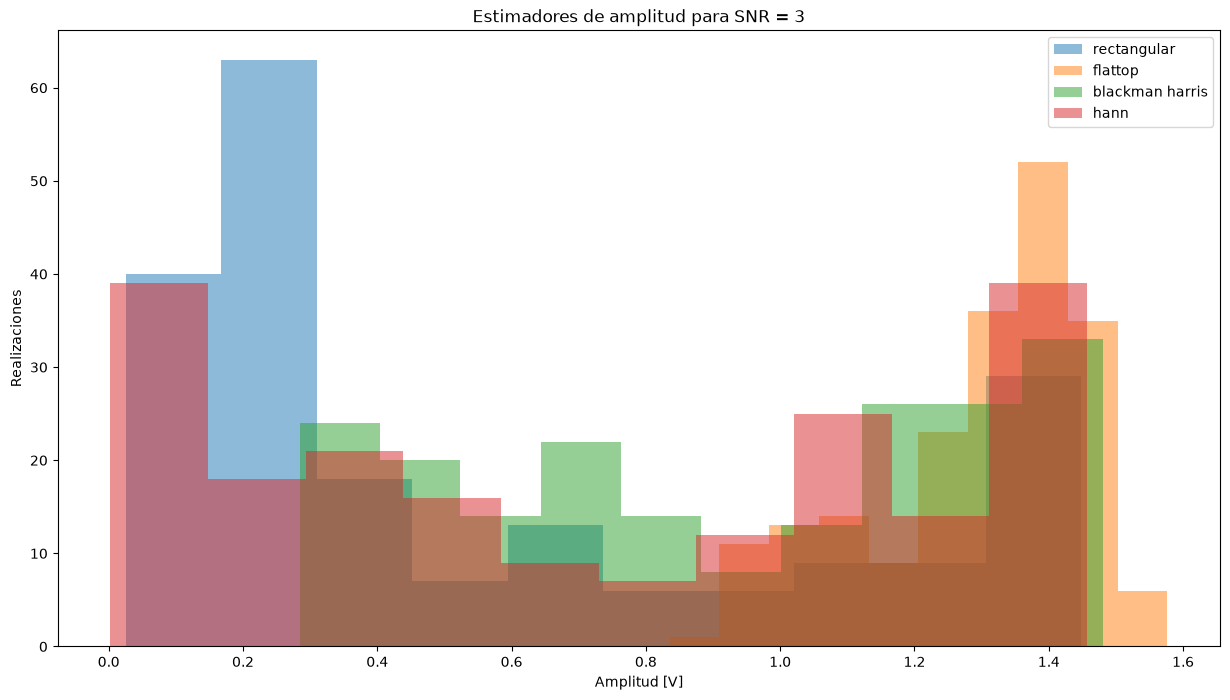

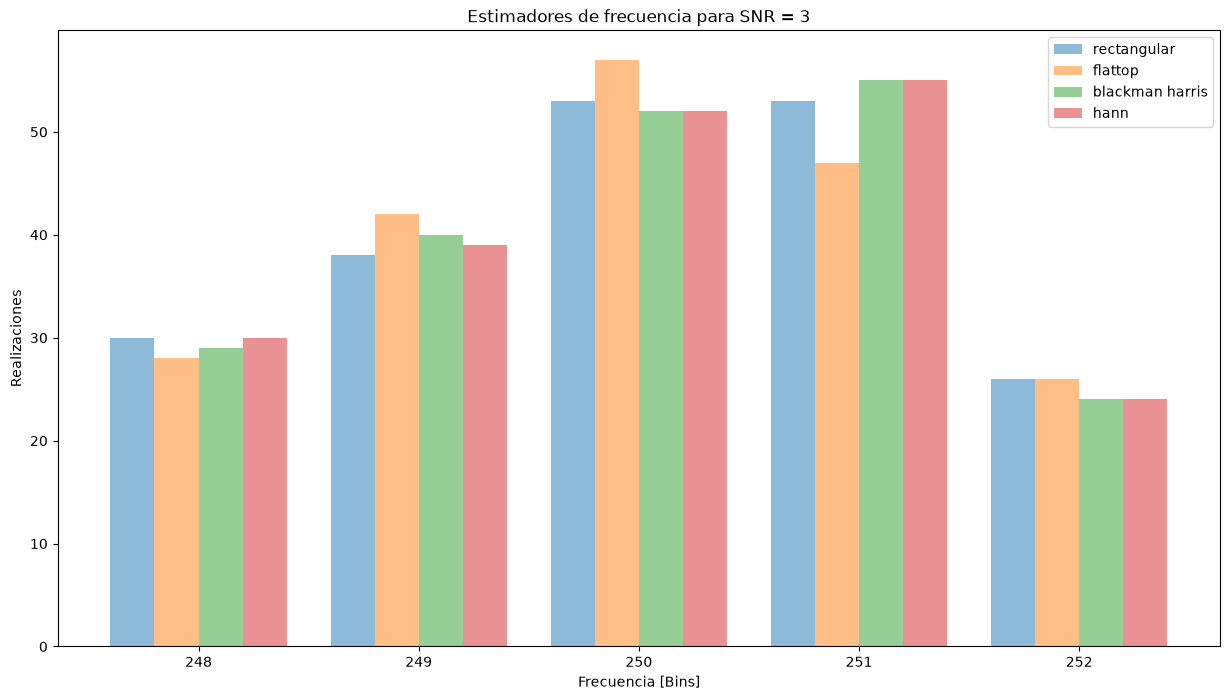

Estimación de Amplitud para SNR = 3
                Sesgo  Varianza
Rectangular -0.869702  0.219861
Flat-top    -0.117974  0.026180
Blackman    -0.489032  0.147804
Hann        -0.693865  0.251168

Estimación de Frecuencia para SNR = 3
             Sesgo  Varianza
Rectangular  0.035  1.573775
Flat-top     0.005  1.524975
Blackman     0.025  1.534375
Hann         0.020  1.549600


In [1]:
import numpy as np
import scipy.signal as sp
import matplotlib.pyplot as plt
import pandas as pd


N = 1000
fs = 1000   # frecuencia de muestreo
R = 200                     
nn = np.arange(0,N).reshape((N,1))  # vector de muestras
df = fs/N                           # Delta f
frec = np.arange(N//2) * fs/N       # vector de frecuencia
Ome_0 = N/4 *df                     #Hz


def mod_sen (señal, ax): #devuelve el modulo de la transformada de la señal
    señal_tr = (1/N) * np.fft.fft(señal, axis=ax)   # fft de la columna (coord 0)
    modulo_señal = 2*np.abs(señal_tr)               # 
    return (modulo_señal)


a0 = np.sqrt(2)
fr = np.random.uniform(-2,2,R).reshape((1,R)) #Hz
Ome_1 = (Ome_0 + fr ) #Hz

snr = 3
pot_ruido = 10**(-snr/10)
na = np.random.normal(0, np.sqrt(pot_ruido), (N,R)) #ver si es 0.1

xx = a0 * np.sin (2*np.pi * Ome_1 * 1/fs*nn) + na

## la ventaneadora
fla = sp.windows.flattop(N).reshape(N,1)
bmh = sp.windows.blackmanharris(N).reshape(N,1)
han = sp.windows.hann(N).reshape(N,1)

a1_rec = mod_sen(xx, 0)
a1_fla = mod_sen(xx*fla, 0) /np.mean(fla)
a1_bmh = mod_sen(xx*bmh, 0) /np.mean(bmh)
a1_han = mod_sen(xx*han, 0) /np.mean(han)

# =============================================================================
# estimador de amplitud de la f en 250 HZ
# =============================================================================
est_amp_rec = a1_rec[(N//4), :]
est_amp_fla = a1_fla[(N//4), :]
est_amp_bmh = a1_bmh[(N//4), :]
est_amp_han = a1_han[(N//4), :]

## historiagrama de los estimadores de amplitud
plt.figure(1,figsize=(15,8))
plt.title(f"Estimadores de amplitud para SNR = {snr}")
plt.xlabel("Amplitud [V]")
plt.ylabel("Realizaciones")
a=0.5
plt.hist(est_amp_rec, alpha=a, label='rectangular')
plt.hist(est_amp_fla, alpha=a, label='flattop')
plt.hist(est_amp_bmh, alpha=a, label='blackman harris')
plt.hist(est_amp_han, alpha=a, label='hann')
plt.legend(loc='upper right')
plt.show()

## varianzovich
var_amp_rec = np.var(est_amp_rec)
var_amp_fla = np.var(est_amp_fla)
var_amp_bmh = np.var(est_amp_bmh)
var_amp_han = np.var(est_amp_han)

## sesguinho
ses_amp_rec = np.mean(est_amp_rec) - a0
ses_amp_fla = np.mean(est_amp_fla) - a0
ses_amp_bmh = np.mean(est_amp_bmh) - a0
ses_amp_han = np.mean(est_amp_han) - a0


# =============================================================================
# estimador de frecuencia
# =============================================================================
est_frec_rec = np.argmax(a1_rec[:N//2], axis = 0)
est_frec_fla = np.argmax(a1_fla[:N//2], axis = 0)
est_frec_bmh = np.argmax(a1_bmh[:N//2], axis = 0)
est_frec_han = np.argmax(a1_han[:N//2], axis = 0)

## histograma de los estimadores de frecuencia
plt.figure(2, figsize=(15,8))
plt.xlabel("Frecuencia [Bins]")
plt.ylabel("Realizaciones")
plt.title(f"Estimadores de frecuencia para SNR = {snr}")
bins_f = np.arange(247.5, 253.5, 1)      # bins centrados en enteros
plt.hist([est_frec_rec, est_frec_fla, est_frec_bmh, est_frec_han],
         bins=bins_f, alpha=a,
         label=['rectangular', 'flattop', 'blackman harris', 'hann'])
plt.xticks(np.arange(248, 253, 1))
plt.legend(loc='upper right')
plt.show()

## varianzovich
var_frec_rec = np.var(est_frec_rec)
var_frec_fla = np.var(est_frec_fla)
var_frec_bmh = np.var(est_frec_bmh)
var_frec_han = np.var(est_frec_han)

## sesguinho
ses_frec_rec = np.mean(est_frec_rec) - Ome_0
ses_frec_fla = np.mean(est_frec_fla) - Ome_0
ses_frec_bmh = np.mean(est_frec_bmh) - Ome_0
ses_frec_han = np.mean(est_frec_han) - Ome_0


# =============================================================================
# tablas tablas
# =============================================================================
ventanas = ["Rectangular", "Flat-top", "Blackman", "Hann"]
columnas = pd.MultiIndex.from_product([["Sesgo", "Varianza"]])

tabla_amplitud = pd.DataFrame(
    {   "Sesgo":    [ses_amp_rec, ses_amp_fla, ses_amp_bmh, ses_amp_han],
        "Varianza": [var_amp_rec, var_amp_fla, var_amp_bmh, var_amp_han],
    },index=ventanas)

tabla_frecuencia = pd.DataFrame(
    {"Sesgo":    [ses_frec_rec, ses_frec_fla, ses_frec_bmh, ses_frec_han],
     "Varianza": [var_frec_rec, var_frec_fla, var_frec_bmh, var_frec_han],
    },index=ventanas)

print(f"Estimación de Amplitud para SNR = {snr}")
print(tabla_amplitud)
print(f"\nEstimación de Frecuencia para SNR = {snr}")
print(tabla_frecuencia)


# =============================================================================
# graficador de dsp de a1
# =============================================================================
# plt.figure(3, figsize=(15,8))
# plt.grid(True)
# plt.plot(a1_rec[:N//2])
# plt.show()

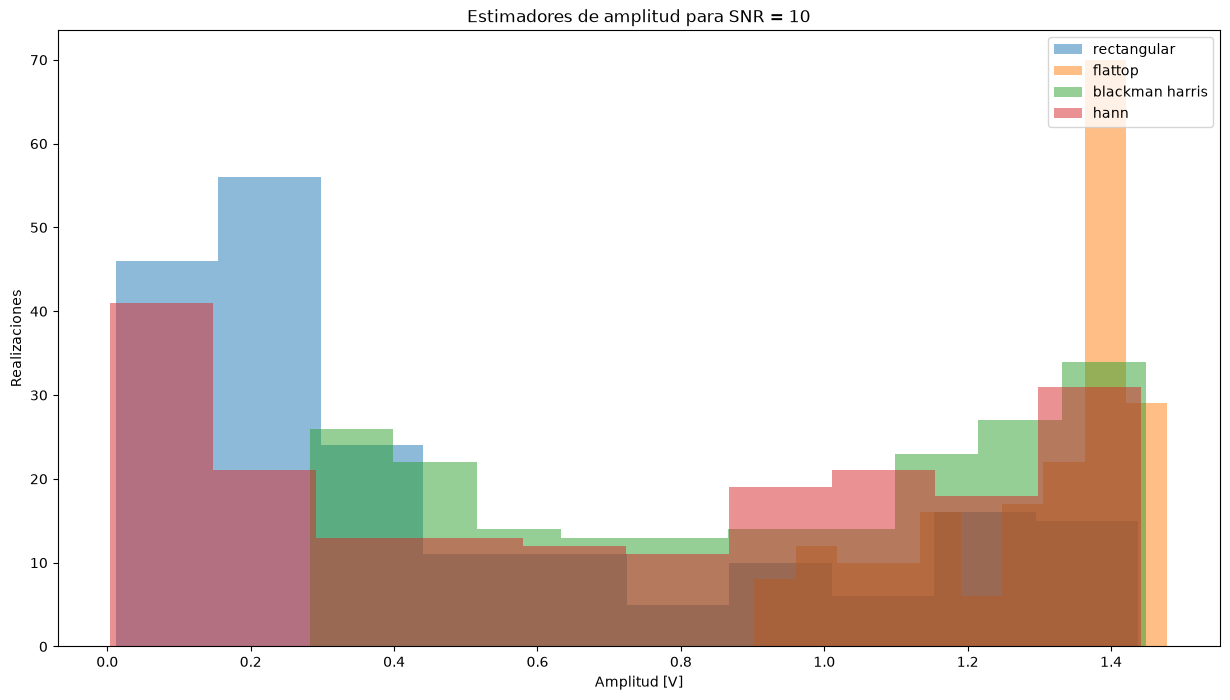

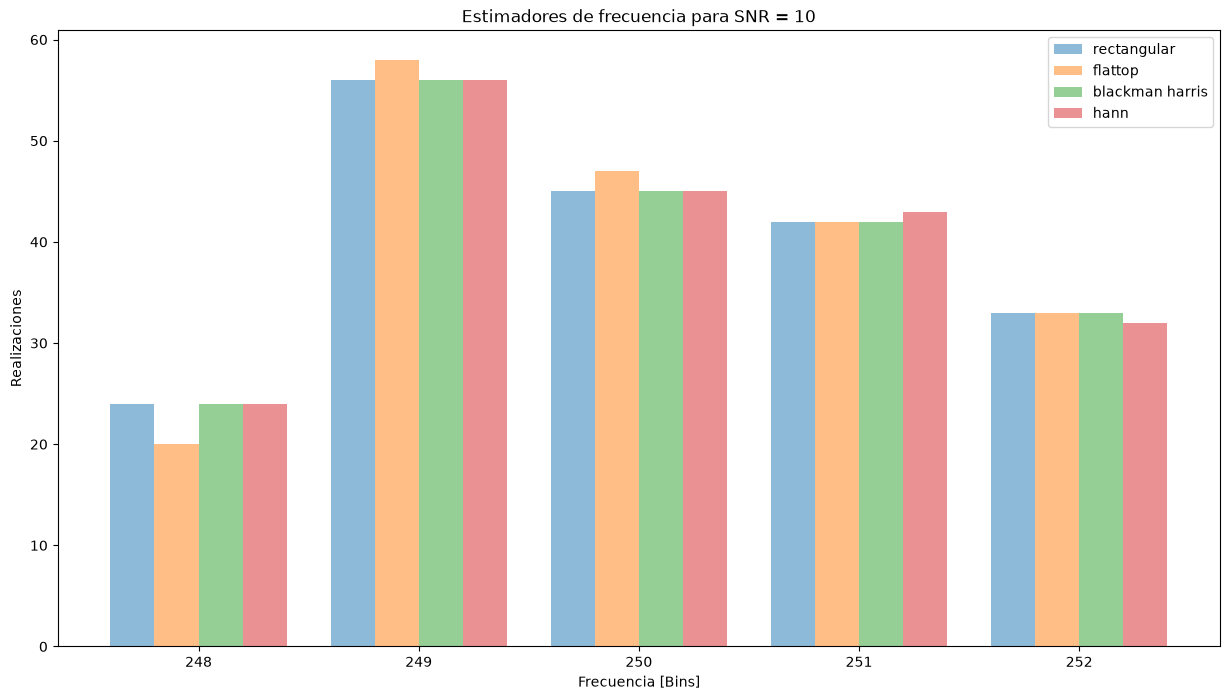

Estimación de Amplitud para SNR = 10
                Sesgo  Varianza
Rectangular -0.921083  0.185073
Flat-top    -0.128071  0.024128
Blackman    -0.505861  0.140531
Hann        -0.717872  0.236005

Estimación de Frecuencia para SNR = 10
             Sesgo  Varianza
Rectangular  0.020  1.629600
Flat-top     0.050  1.557500
Blackman     0.020  1.629600
Hann         0.015  1.614775


In [2]:
# -*- coding: utf-8 -*-
"""
Created on Wed Sep  9 18:59:48 2026

@author: bruno
"""

import numpy as np
import scipy.signal as sp
import matplotlib.pyplot as plt
import pandas as pd


N = 1000
fs = 1000   # frecuencia de muestreo
R = 200                     
nn = np.arange(0,N).reshape((N,1))  # vector de muestras
df = fs/N                           # Delta f
frec = np.arange(N//2) * fs/N       # vector de frecuencia
Ome_0 = N/4 *df                     #Hz


def mod_sen (señal, ax): #devuelve el modulo de la transformada de la señal
    señal_tr = (1/N) * np.fft.fft(señal, axis=ax)   # fft de la columna (coord 0)
    modulo_señal = 2*np.abs(señal_tr)               # 
    return (modulo_señal)


a0 = np.sqrt(2)
fr = np.random.uniform(-2,2,R).reshape((1,R)) #Hz
Ome_1 = (Ome_0 + fr ) #Hz

snr = 10
pot_ruido = 10**(-snr/10)
na = np.random.normal(0, np.sqrt(pot_ruido), (N,R)) #ver si es 0.1

xx = a0 * np.sin (2*np.pi * Ome_1 * 1/fs*nn) + na

## la ventaneadora
fla = sp.windows.flattop(N).reshape(N,1)
bmh = sp.windows.blackmanharris(N).reshape(N,1)
han = sp.windows.hann(N).reshape(N,1)

a1_rec = mod_sen(xx, 0)
a1_fla = mod_sen(xx*fla, 0) /np.mean(fla)
a1_bmh = mod_sen(xx*bmh, 0) /np.mean(bmh)
a1_han = mod_sen(xx*han, 0) /np.mean(han)

# =============================================================================
# estimador de amplitud de la f en 250 HZ
# =============================================================================
est_amp_rec = a1_rec[(N//4), :]
est_amp_fla = a1_fla[(N//4), :]
est_amp_bmh = a1_bmh[(N//4), :]
est_amp_han = a1_han[(N//4), :]

## historiagrama de los estimadores de amplitud
plt.figure(1,figsize=(15,8))
plt.title(f"Estimadores de amplitud para SNR = {snr}")
plt.xlabel("Amplitud [V]")
plt.ylabel("Realizaciones")
a=0.5
plt.hist(est_amp_rec, alpha=a, label='rectangular')
plt.hist(est_amp_fla, alpha=a, label='flattop')
plt.hist(est_amp_bmh, alpha=a, label='blackman harris')
plt.hist(est_amp_han, alpha=a, label='hann')
plt.legend(loc='upper right')
plt.show()

## varianzovich
var_amp_rec = np.var(est_amp_rec)
var_amp_fla = np.var(est_amp_fla)
var_amp_bmh = np.var(est_amp_bmh)
var_amp_han = np.var(est_amp_han)

## sesguinho
ses_amp_rec = np.mean(est_amp_rec) - a0
ses_amp_fla = np.mean(est_amp_fla) - a0
ses_amp_bmh = np.mean(est_amp_bmh) - a0
ses_amp_han = np.mean(est_amp_han) - a0


# =============================================================================
# estimador de frecuencia
# =============================================================================
est_frec_rec = np.argmax(a1_rec[:N//2], axis = 0)
est_frec_fla = np.argmax(a1_fla[:N//2], axis = 0)
est_frec_bmh = np.argmax(a1_bmh[:N//2], axis = 0)
est_frec_han = np.argmax(a1_han[:N//2], axis = 0)

## histograma de los estimadores de frecuencia
plt.figure(2, figsize=(15,8))
plt.xlabel("Frecuencia [Bins]")
plt.ylabel("Realizaciones")
plt.title(f"Estimadores de frecuencia para SNR = {snr}")
bins_f = np.arange(247.5, 253.5, 1)      # bins centrados en enteros
plt.hist([est_frec_rec, est_frec_fla, est_frec_bmh, est_frec_han],
         bins=bins_f, alpha=a,
         label=['rectangular', 'flattop', 'blackman harris', 'hann'])
plt.xticks(np.arange(248, 253, 1))
plt.legend(loc='upper right')
plt.show()

## varianzovich
var_frec_rec = np.var(est_frec_rec)
var_frec_fla = np.var(est_frec_fla)
var_frec_bmh = np.var(est_frec_bmh)
var_frec_han = np.var(est_frec_han)

## sesguinho
ses_frec_rec = np.mean(est_frec_rec) - Ome_0
ses_frec_fla = np.mean(est_frec_fla) - Ome_0
ses_frec_bmh = np.mean(est_frec_bmh) - Ome_0
ses_frec_han = np.mean(est_frec_han) - Ome_0


# =============================================================================
# tablas tablas
# =============================================================================
ventanas = ["Rectangular", "Flat-top", "Blackman", "Hann"]
columnas = pd.MultiIndex.from_product([["Sesgo", "Varianza"]])

tabla_amplitud = pd.DataFrame(
    {   "Sesgo":    [ses_amp_rec, ses_amp_fla, ses_amp_bmh, ses_amp_han],
        "Varianza": [var_amp_rec, var_amp_fla, var_amp_bmh, var_amp_han],
    },index=ventanas)

tabla_frecuencia = pd.DataFrame(
    {"Sesgo":    [ses_frec_rec, ses_frec_fla, ses_frec_bmh, ses_frec_han],
     "Varianza": [var_frec_rec, var_frec_fla, var_frec_bmh, var_frec_han],
    },index=ventanas)

print(f"Estimación de Amplitud para SNR = {snr}")
print(tabla_amplitud)
print(f"\nEstimación de Frecuencia para SNR = {snr}")
print(tabla_frecuencia)


# =============================================================================
# graficador de dsp de a1
# =============================================================================
# plt.figure(3, figsize=(15,8))
# plt.grid(True)
# plt.plot(a1_rec[:N//2])
# plt.show()